<a href="https://colab.research.google.com/github/swapna0727-source/AI/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("transactions.csv")
print(df["is_fraud"].value_counts())
print(df["is_fraud"].value_counts(normalize=True))

is_fraud
0    27
1     8
Name: count, dtype: int64
is_fraud
0    0.771429
1    0.228571
Name: proportion, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   transaction_id     35 non-null     int64 
 1   amount             35 non-null     int64 
 2   merchant_category  35 non-null     object
 3   hour_of_day        35 non-null     int64 
 4   is_fraud           35 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB


In [ ]:
df.head()

,transaction_id,amount,merchant_category,hour_of_day,is_fraud
0,5001,1200,Electronics,23,1
1,5002,45,Grocery,10,0
2,5003,60,Grocery,11,0
3,5004,3200,Electronics,2,1
4,5005,25,Grocery,9,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
df.head()

,transaction_id,amount,merchant_category,hour_of_day,is_fraud
0,5001,1200,Electronics,23,1
1,5002,45,Grocery,10,0
2,5003,60,Grocery,11,0
3,5004,3200,Electronics,2,1
4,5005,25,Grocery,9,0


In [ ]:
X = df[["amount","hour_of_day"]]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

model = LogisticRegression()

model.fit(X_train, y_train) # model learns the paramaters / coefficients

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)




[[5 0]
 [0 2]]


In [ ]:
y_test.value_counts()

,count
is_fraud,
0,5
1,2


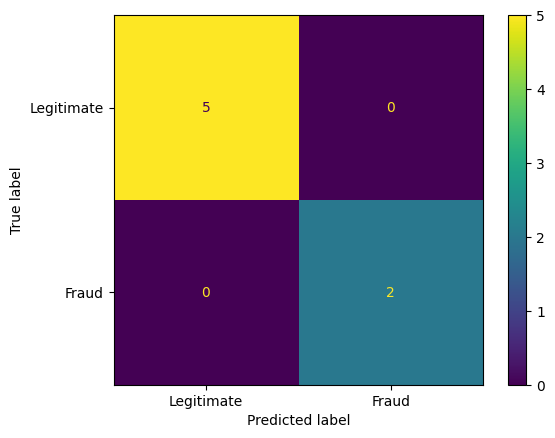

In [ ]:
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"]).plot()
plt.show()

In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1 )

Precision:  1.0
Recall:  1.0
F1 Score:  1.0


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         2

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [ ]:
y_pred

array([0, 0, 0, 1, 0, 1, 0])

In [ ]:
probs = model.predict_proba(X_test)[:, 1]

In [ ]:
probs

array([1.72900978e-06, 1.06430626e-06, 1.20788818e-06, 1.00000000e+00,
       9.78215654e-07, 1.00000000e+00, 8.80303617e-07])

In [ ]:
probs = model.predict_proba(X_test)[:, 1]

for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    preds_at_t = (probs >= t).astype(int)
    p = precision_score(y_test, preds_at_t, zero_division=0)
    r = recall_score(y_test, preds_at_t, zero_division=0)
    print(f"threshold={t}: precision={p:.3f}, recall={r:.3f}")

threshold=0.1: precision=1.000, recall=1.000
threshold=0.3: precision=1.000, recall=1.000
threshold=0.5: precision=1.000, recall=1.000
threshold=0.7: precision=1.000, recall=1.000
threshold=0.9: precision=1.000, recall=1.000


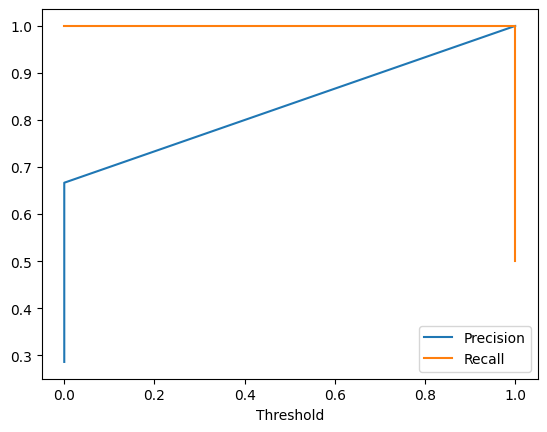

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()